
KKT residuals (without regularization):
  Stationarity: 1.47e-02
  Primal feas.: 9.86e-04


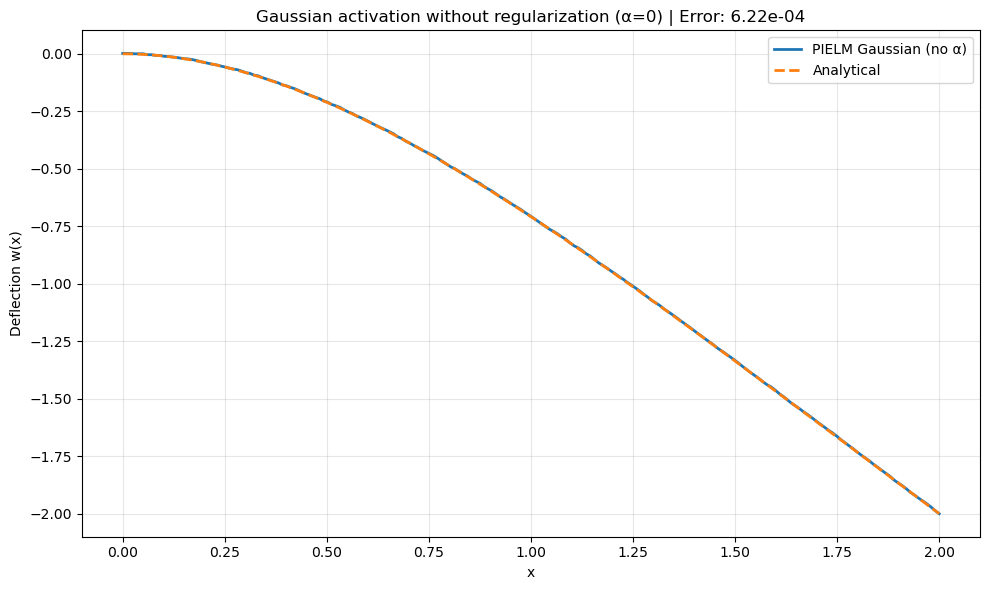

Training time: 0.1084 s
Relative error: 6.22e-04
β₀ = -11142.464844

First 5 β values:
  β₀ = -11142.464844
  β1 = -0.007792
  β2 = -0.065952
  β3 = -8.713393
  β4 = 0.002400

Lagrange multipliers λ:
  λ1 = 0.000000
  λ2 = 0.000000
  λ3 = -0.000002
  λ4 = -0.000000

NOTE: This version uses GAUSSIAN activation WITHOUT regularization (α=0)


In [2]:
import torch
import torch.autograd as autograd
import matplotlib.pyplot as plt
from timeit import default_timer

# =============================================================================
# PHYSICAL PARAMETERS
# =============================================================================
E, I = 1.0, 1.0
Q = -1.0
L = 2.0

# =============================================================================
# ANALYTICAL SOLUTION
# =============================================================================
def analytical_solution(x):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# PIELM SETUP WITH GAUSSIAN ACTIVATION (NO REGULARIZATION)
# =============================================================================
torch.manual_seed(42)

hidden_size = 40
W = torch.randn(1, hidden_size)
b = torch.randn(hidden_size)

def hidden_layer_gaussian(x):
    """Gaussian activation: exp(-(Wx + b)^2) with bias term"""
    H_gaussian = torch.exp(-(x @ W + b)**2)
    ones = torch.ones(x.shape[0], 1)
    H_with_bias = torch.cat([ones, H_gaussian], dim=1)
    return H_with_bias

# =============================================================================
# COLLOCATION & BOUNDARY POINTS
# =============================================================================
n_collocation = 100
x_c = torch.linspace(0, L, n_collocation).view(-1, 1).requires_grad_(True)
x_0 = torch.tensor([[0.0]], requires_grad=True)
x_L = torch.tensor([[L]], requires_grad=True)

# =============================================================================
# BUILD PDE MATRIX A
# =============================================================================
t0 = default_timer()

H_c = hidden_layer_gaussian(x_c)
A_cols = []

# β₀ term (constant function)
zero_col = torch.zeros(n_collocation, 1)
A_cols.append(zero_col)

# β₁ to β₄₀ terms
for j in range(1, hidden_size + 1):
    wj = H_c[:, j:j+1]
    w_x = autograd.grad(wj.sum(), x_c, create_graph=True)[0]
    w_xx = autograd.grad(w_x.sum(), x_c, create_graph=True)[0]
    w_xxx = autograd.grad(w_xx.sum(), x_c, create_graph=True)[0]
    w_xxxx = autograd.grad(w_xxx.sum(), x_c, create_graph=True)[0]
    A_cols.append(w_xxxx)

A = E * I * torch.hstack(A_cols)
b_pde = Q * torch.ones(n_collocation, 1)

# =============================================================================
# BUILD BOUNDARY CONSTRAINT MATRIX C
# =============================================================================
def bc_row(x, order):
    H = hidden_layer_gaussian(x)
    row = []
    
    # β₀ term
    if order == 0:
        row.append(torch.ones(1, 1))
    else:
        row.append(torch.zeros(1, 1))
    
    # β₁ to β₄₀ terms
    for j in range(1, hidden_size + 1):
        w = H[:, j:j+1]
        for _ in range(order):
            w = autograd.grad(w.sum(), x, create_graph=True)[0] if w.requires_grad else w
        row.append(w)
    
    return torch.hstack(row)

C = torch.vstack([
    bc_row(x_0, 0),   # w(0) = 0
    bc_row(x_0, 1),   # w'(0) = 0
    bc_row(x_L, 2),   # w''(L) = 0
    bc_row(x_L, 3)    # w'''(L) = 0
])

d = torch.zeros(4, 1)

# =============================================================================
# KKT SYSTEM WITHOUT REGULARIZATION (α=0)
# =============================================================================
total_beta = hidden_size + 1
total_unknowns = total_beta + 4

KKT = torch.zeros(total_unknowns, total_unknowns)
KKT[:total_beta, :total_beta] = A.T @ A
KKT[:total_beta, total_beta:] = C.T
KKT[total_beta:, :total_beta] = C

rhs = torch.vstack([A.T @ b_pde, d])

# NO REGULARIZATION - α = 0
# KKT += 0 * torch.eye(total_unknowns)  # Commented out to show α=0

solution = torch.linalg.solve(KKT, rhs)
beta_with_b0 = solution[:total_beta]
lambdas = solution[total_beta:]

# =============================================================================
# VERIFY KKT CONDITIONS
# =============================================================================
stationarity = A.T @ (A @ beta_with_b0 - b_pde) + C.T @ lambdas
primal = C @ beta_with_b0 - d

print("\nKKT residuals (without regularization):")
print(f"  Stationarity: {torch.norm(stationarity):.2e}")
print(f"  Primal feas.: {torch.norm(primal):.2e}")

# =============================================================================
# PREDICTION AND PLOT
# =============================================================================
x_pred = torch.linspace(0, L, 200).view(-1, 1)
H_pred = hidden_layer_gaussian(x_pred)
w_pred = H_pred @ beta_with_b0
w_exact = analytical_solution(x_pred)
rel_error = torch.mean(torch.abs(w_pred - w_exact)) / torch.max(torch.abs(w_exact))

plt.figure(figsize=(10, 6))
plt.plot(x_pred, w_pred.detach(), label="PIELM Gaussian (no α)", linewidth=2)
plt.plot(x_pred, w_exact, "--", label="Analytical", linewidth=2)
plt.xlabel("x")
plt.ylabel("Deflection w(x)")
plt.title(f"Gaussian activation without regularization (α=0) | Error: {rel_error.item():.2e}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Training time: {default_timer() - t0:.4f} s")
print(f"Relative error: {rel_error.item():.2e}")
print(f"β₀ = {beta_with_b0[0].item():.6f}")

print("\nFirst 5 β values:")
for i in range(min(5, len(beta_with_b0))):
    if i == 0:
        print(f"  β₀ = {beta_with_b0[i].item():.6f}")
    else:
        print(f"  β{i} = {beta_with_b0[i].item():.6f}")

print("\nLagrange multipliers λ:")
for i, lam in enumerate(lambdas):
    print(f"  λ{i+1} = {lam.item():.6f}")

print("\n" + "="*60)
print("NOTE: This version uses GAUSSIAN activation WITHOUT regularization (α=0)")
print("="*60)


KKT residuals (without regularization):
  Stationarity: 7.01e-02
  Primal feas.: 4.75e+00


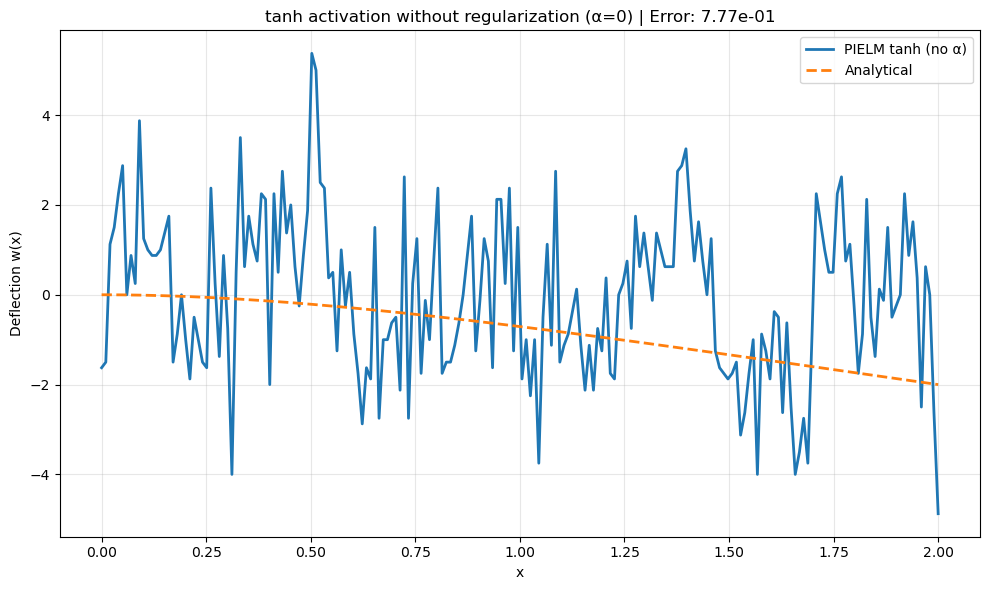

Training time: 0.1316 s
Relative error: 7.77e-01
β₀ = -21691600.000000

First 5 β values:
  β₀ = -21691600.000000
  β1 = 0.035913
  β2 = -0.038074
  β3 = -89.516457
  β4 = -0.082093

Lagrange multipliers λ:
  λ1 = 0.000000
  λ2 = 0.000001
  λ3 = -0.000059
  λ4 = 0.000771

NOTE: This version uses TANH activation WITHOUT regularization (α=0)


In [3]:
import torch
import torch.autograd as autograd
import matplotlib.pyplot as plt
from timeit import default_timer

# =============================================================================
# PHYSICAL PARAMETERS
# =============================================================================
E, I = 1.0, 1.0
Q = -1.0
L = 2.0

# =============================================================================
# ANALYTICAL SOLUTION
# =============================================================================
def analytical_solution(x):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# PIELM SETUP WITH tanh ACTIVATION (NO REGULARIZATION)
# =============================================================================
torch.manual_seed(42)

hidden_size = 40
W = torch.randn(1, hidden_size)
b = torch.randn(hidden_size)

def hidden_layer_tanh(x):
    """tanh activation: tanh(Wx + b) with bias term"""
    H_tanh = torch.tanh(x @ W + b)
    ones = torch.ones(x.shape[0], 1)
    H_with_bias = torch.cat([ones, H_tanh], dim=1)
    return H_with_bias

# =============================================================================
# COLLOCATION & BOUNDARY POINTS
# =============================================================================
n_collocation = 100
x_c = torch.linspace(0, L, n_collocation).view(-1, 1).requires_grad_(True)
x_0 = torch.tensor([[0.0]], requires_grad=True)
x_L = torch.tensor([[L]], requires_grad=True)

# =============================================================================
# BUILD PDE MATRIX A
# =============================================================================
t0 = default_timer()

H_c = hidden_layer_tanh(x_c)
A_cols = []

# β₀ term (constant function)
zero_col = torch.zeros(n_collocation, 1)
A_cols.append(zero_col)

# β₁ to β₄₀ terms
for j in range(1, hidden_size + 1):
    wj = H_c[:, j:j+1]
    w_x = autograd.grad(wj.sum(), x_c, create_graph=True)[0]
    w_xx = autograd.grad(w_x.sum(), x_c, create_graph=True)[0]
    w_xxx = autograd.grad(w_xx.sum(), x_c, create_graph=True)[0]
    w_xxxx = autograd.grad(w_xxx.sum(), x_c, create_graph=True)[0]
    A_cols.append(w_xxxx)

A = E * I * torch.hstack(A_cols)
b_pde = Q * torch.ones(n_collocation, 1)

# =============================================================================
# BUILD BOUNDARY CONSTRAINT MATRIX C
# =============================================================================
def bc_row(x, order):
    H = hidden_layer_tanh(x)
    row = []
    
    # β₀ term
    if order == 0:
        row.append(torch.ones(1, 1))
    else:
        row.append(torch.zeros(1, 1))
    
    # β₁ to β₄₀ terms
    for j in range(1, hidden_size + 1):
        w = H[:, j:j+1]
        for _ in range(order):
            w = autograd.grad(w.sum(), x, create_graph=True)[0] if w.requires_grad else w
        row.append(w)
    
    return torch.hstack(row)

C = torch.vstack([
    bc_row(x_0, 0),   # w(0) = 0
    bc_row(x_0, 1),   # w'(0) = 0
    bc_row(x_L, 2),   # w''(L) = 0
    bc_row(x_L, 3)    # w'''(L) = 0
])

d = torch.zeros(4, 1)

# =============================================================================
# KKT SYSTEM WITHOUT REGULARIZATION (α=0)
# =============================================================================
total_beta = hidden_size + 1
total_unknowns = total_beta + 4

KKT = torch.zeros(total_unknowns, total_unknowns)
KKT[:total_beta, :total_beta] = A.T @ A
KKT[:total_beta, total_beta:] = C.T
KKT[total_beta:, :total_beta] = C

rhs = torch.vstack([A.T @ b_pde, d])

# NO REGULARIZATION - α = 0
# KKT += 0 * torch.eye(total_unknowns)  # Commented out to show α=0

solution = torch.linalg.solve(KKT, rhs)
beta_with_b0 = solution[:total_beta]
lambdas = solution[total_beta:]

# =============================================================================
# VERIFY KKT CONDITIONS
# =============================================================================
stationarity = A.T @ (A @ beta_with_b0 - b_pde) + C.T @ lambdas
primal = C @ beta_with_b0 - d

print("\nKKT residuals (without regularization):")
print(f"  Stationarity: {torch.norm(stationarity):.2e}")
print(f"  Primal feas.: {torch.norm(primal):.2e}")

# =============================================================================
# PREDICTION AND PLOT
# =============================================================================
x_pred = torch.linspace(0, L, 200).view(-1, 1)
H_pred = hidden_layer_tanh(x_pred)
w_pred = H_pred @ beta_with_b0
w_exact = analytical_solution(x_pred)
rel_error = torch.mean(torch.abs(w_pred - w_exact)) / torch.max(torch.abs(w_exact))

plt.figure(figsize=(10, 6))
plt.plot(x_pred, w_pred.detach(), label="PIELM tanh (no α)", linewidth=2)
plt.plot(x_pred, w_exact, "--", label="Analytical", linewidth=2)
plt.xlabel("x")
plt.ylabel("Deflection w(x)")
plt.title(f"tanh activation without regularization (α=0) | Error: {rel_error.item():.2e}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Training time: {default_timer() - t0:.4f} s")
print(f"Relative error: {rel_error.item():.2e}")
print(f"β₀ = {beta_with_b0[0].item():.6f}")

print("\nFirst 5 β values:")
for i in range(min(5, len(beta_with_b0))):
    if i == 0:
        print(f"  β₀ = {beta_with_b0[i].item():.6f}")
    else:
        print(f"  β{i} = {beta_with_b0[i].item():.6f}")

print("\nLagrange multipliers λ:")
for i, lam in enumerate(lambdas):
    print(f"  λ{i+1} = {lam.item():.6f}")

print("\n" + "="*60)
print("NOTE: This version uses TANH activation WITHOUT regularization (α=0)")
print("="*60)


KKT residuals (without regularization):
  Stationarity: 5.49e-04
  Primal feas.: 1.25e-01


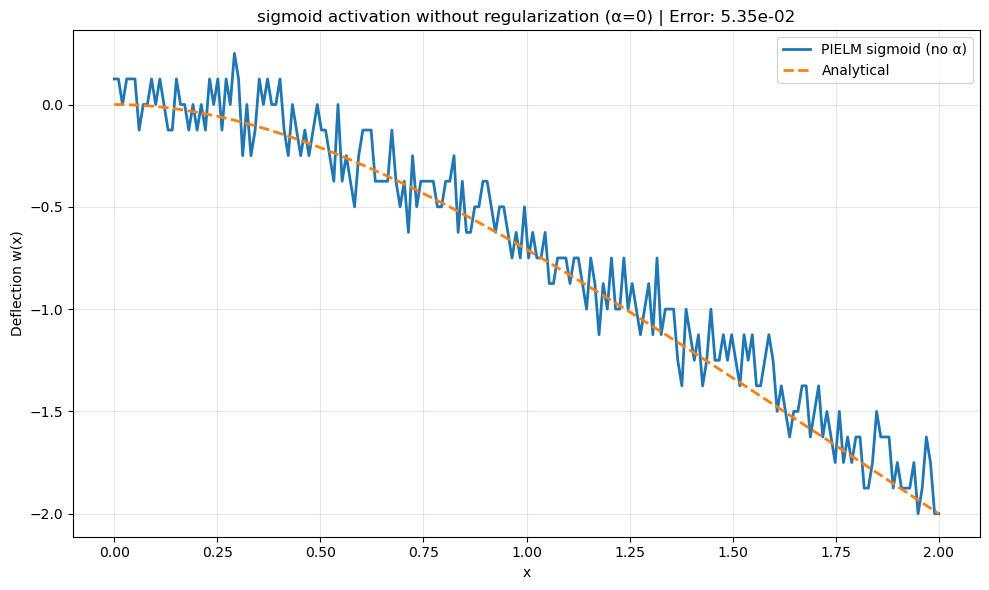

Training time: 0.0881 s
Relative error: 5.35e-02
β₀ = 1398034.750000

First 5 β values:
  β₀ = 1398034.750000
  β1 = 2.019881
  β2 = 8.554009
  β3 = 474.982208
  β4 = -2.035730

Lagrange multipliers λ:
  λ1 = 0.000000
  λ2 = -0.000002
  λ3 = 0.000050
  λ4 = 0.000207

NOTE: This version uses SIGMOID activation WITHOUT regularization (α=0)


In [5]:
import torch
import torch.autograd as autograd
import matplotlib.pyplot as plt
from timeit import default_timer

# =============================================================================
# PHYSICAL PARAMETERS
# =============================================================================
E, I = 1.0, 1.0
Q = -1.0
L = 2.0

# =============================================================================
# ANALYTICAL SOLUTION
# =============================================================================
def analytical_solution(x):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# PIELM SETUP WITH sigmoid ACTIVATION (NO REGULARIZATION)
# =============================================================================
torch.manual_seed(42)

hidden_size = 40
W = torch.randn(1, hidden_size)
b = torch.randn(hidden_size)

def hidden_layer_sigmoid(x):
    """sigmoid activation: sigmoid(Wx + b) with bias term"""
    H_sigmoid = torch.sigmoid(x @ W + b)
    ones = torch.ones(x.shape[0], 1)
    H_with_bias = torch.cat([ones, H_sigmoid], dim=1)
    return H_with_bias

# =============================================================================
# COLLOCATION & BOUNDARY POINTS
# =============================================================================
n_collocation = 100
x_c = torch.linspace(0, L, n_collocation).view(-1, 1).requires_grad_(True)
x_0 = torch.tensor([[0.0]], requires_grad=True)
x_L = torch.tensor([[L]], requires_grad=True)

# =============================================================================
# BUILD PDE MATRIX A
# =============================================================================
t0 = default_timer()

H_c = hidden_layer_sigmoid(x_c)
A_cols = []

# β₀ term (constant function)
zero_col = torch.zeros(n_collocation, 1)
A_cols.append(zero_col)

# β₁ to β₄₀ terms
for j in range(1, hidden_size + 1):
    wj = H_c[:, j:j+1]
    w_x = autograd.grad(wj.sum(), x_c, create_graph=True)[0]
    w_xx = autograd.grad(w_x.sum(), x_c, create_graph=True)[0]
    w_xxx = autograd.grad(w_xx.sum(), x_c, create_graph=True)[0]
    w_xxxx = autograd.grad(w_xxx.sum(), x_c, create_graph=True)[0]
    A_cols.append(w_xxxx)

A = E * I * torch.hstack(A_cols)
b_pde = Q * torch.ones(n_collocation, 1)

# =============================================================================
# BUILD BOUNDARY CONSTRAINT MATRIX C
# =============================================================================
def bc_row(x, order):
    H = hidden_layer_sigmoid(x)
    row = []
    
    # β₀ term
    if order == 0:
        row.append(torch.ones(1, 1))
    else:
        row.append(torch.zeros(1, 1))
    
    # β₁ to β₄₀ terms
    for j in range(1, hidden_size + 1):
        w = H[:, j:j+1]
        for _ in range(order):
            w = autograd.grad(w.sum(), x, create_graph=True)[0] if w.requires_grad else w
        row.append(w)
    
    return torch.hstack(row)

C = torch.vstack([
    bc_row(x_0, 0),   # w(0) = 0
    bc_row(x_0, 1),   # w'(0) = 0
    bc_row(x_L, 2),   # w''(L) = 0
    bc_row(x_L, 3)    # w'''(L) = 0
])

d = torch.zeros(4, 1)

# =============================================================================
# KKT SYSTEM WITHOUT REGULARIZATION (α=0)
# =============================================================================
total_beta = hidden_size + 1
total_unknowns = total_beta + 4

KKT = torch.zeros(total_unknowns, total_unknowns)
KKT[:total_beta, :total_beta] = A.T @ A
KKT[:total_beta, total_beta:] = C.T
KKT[total_beta:, :total_beta] = C

rhs = torch.vstack([A.T @ b_pde, d])

# NO REGULARIZATION - α = 0
# KKT += 0 * torch.eye(total_unknowns)  # Commented out to show α=0

solution = torch.linalg.solve(KKT, rhs)
beta_with_b0 = solution[:total_beta]
lambdas = solution[total_beta:]

# =============================================================================
# VERIFY KKT CONDITIONS
# =============================================================================
stationarity = A.T @ (A @ beta_with_b0 - b_pde) + C.T @ lambdas
primal = C @ beta_with_b0 - d

print("\nKKT residuals (without regularization):")
print(f"  Stationarity: {torch.norm(stationarity):.2e}")
print(f"  Primal feas.: {torch.norm(primal):.2e}")

# =============================================================================
# PREDICTION AND PLOT
# =============================================================================
x_pred = torch.linspace(0, L, 200).view(-1, 1)
H_pred = hidden_layer_sigmoid(x_pred)
w_pred = H_pred @ beta_with_b0
w_exact = analytical_solution(x_pred)
rel_error = torch.mean(torch.abs(w_pred - w_exact)) / torch.max(torch.abs(w_exact))

plt.figure(figsize=(10, 6))
plt.plot(x_pred, w_pred.detach(), label="PIELM sigmoid (no α)", linewidth=2)
plt.plot(x_pred, w_exact, "--", label="Analytical", linewidth=2)
plt.xlabel("x")
plt.ylabel("Deflection w(x)")
plt.title(f"sigmoid activation without regularization (α=0) | Error: {rel_error.item():.2e}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Training time: {default_timer() - t0:.4f} s")
print(f"Relative error: {rel_error.item():.2e}")
print(f"β₀ = {beta_with_b0[0].item():.6f}")

print("\nFirst 5 β values:")
for i in range(min(5, len(beta_with_b0))):
    if i == 0:
        print(f"  β₀ = {beta_with_b0[i].item():.6f}")
    else:
        print(f"  β{i} = {beta_with_b0[i].item():.6f}")

print("\nLagrange multipliers λ:")
for i, lam in enumerate(lambdas):
    print(f"  λ{i+1} = {lam.item():.6f}")

print("\n" + "="*60)
print("NOTE: This version uses SIGMOID activation WITHOUT regularization (α=0)")
print("="*60)